In [ ]:
import gdown
import zipfile
import os
import shutil

In [ ]:
# Google Drive link
file_url = "https://drive.google.com/file/d/1oUX991nPh4330ZzbXzBKKOAswhx75BtV/view?usp=sharing"

# Output filename
output = "dataset.zip"


In [ ]:
# Download directly from Google Drive
gdown.download(file_url, output, quiet = False, fuzzy = True)

# Extract the zip file
extract_dir = "/content/images"
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

Downloading...
From (original): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV
From (redirected): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV&confirm=t&uuid=e01ca25f-8049-479c-ae79-272f54854d44
To: /content/dataset.zip

  0%|          | 0.00/9.26G [00:00<?, ?B/s]
  0%|          | 4.72M/9.26G [00:00<06:41, 23.0MB/s]
  0%|          | 7.34M/9.26G [00:00<06:28, 23.8MB/s]
  0%|          | 11.0M/9.26G [00:00<05:52, 26.2MB/s]
  0%|          | 27.8M/9.26G [00:00<03:10, 48.5MB/s]
  0%|          | 42.5M/9.26G [00:00<02:08, 71.7MB/s]
  1%|          | 50.9M/9.26G [00:00<02:25, 63.4MB/s]
  1%|          | 58.2M/9.26G [00:01<03:23, 45.2MB/s]
  1%|          | 80.2M/9.26G [00:01<02:23, 64.2MB/s]
  1%|          | 90.7M/9.26G [00:01<02:12, 69.4MB/s]
  1%|          | 98.6M/9.26G [00:01<02:39, 57.5MB/s]
  1%|          | 105M/9.26G [00:01<02:44, 55.7MB/s] 
  1%|          | 112M/9.26G [00:02<03:02, 50.2MB/s]
  1%|▏         | 124M/9.26G [00:02<02:20, 65.1MB/s]
  1%|▏    

Loading images

In [ ]:
import random
import zipfile
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [ ]:
print("Total files extracted:", sum(len(files) for _, _, files in os.walk("/content/images")))
print("Sample files:", os.listdir("/content/images")[:10])

Total files extracted: 34731
Sample files: ['images']


In [ ]:
image_dir = f"{extract_dir}/images/"

In [ ]:
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg') or f.endswith('.png')]

In [ ]:
# List files in the image directory
print(os.listdir(image_dir))

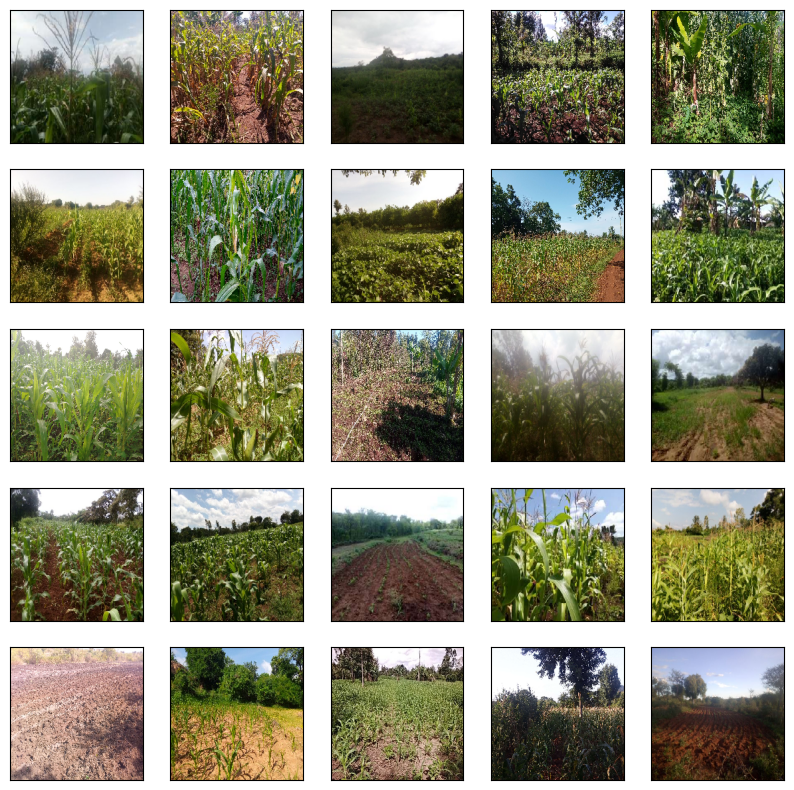

In [ ]:
plt.figure(figsize = (10, 10))
# Select a subset of image files to display
sample_files = random.sample(image_files, min(25, len(image_files)))
for i, file in enumerate(sample_files):
  img_path = os.path.join(image_dir, file)
  img = image.load_img(img_path, target_size = (200, 200))  # Adjust the target size as needed
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(img)
plt.show()

In [ ]:
from PIL import Image
from tqdm import tqdm
import hashlib
import pandas as pd

In [ ]:
input_dir = "/content/images"

In [ ]:
# pick first 10 image paths
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [ ]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


Checking for corrupted images

In [68]:
bad_files = []

for path in tqdm(image_files, desc = "Checking for corrupted images"):
    try:
        img = Image.open(path)
        img.verify()  # check if corrupted
    except Exception:
        bad_files.append(path)
        os.remove(path)

print(f"✅ Removed {len(bad_files)} corrupted images")

Checking for corrupted images: 100%|██████████| 34731/34731 [00:10<00:00, 3451.68it/s]

✅ Removed 0 corrupted images


Checking for duplicates

In [69]:
seen = set()
duplicates = []

for path in tqdm(image_files, desc = "Checking for duplicates"):
    try:
        with open(path, "rb") as f:
            hash_val = hashlib.md5(f.read()).hexdigest()
        if hash_val in seen:
            os.remove(path)
            duplicates.append(path)
        else:
            seen.add(hash_val)
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(path)}: {e}")

print(f"✅ Removed {len(duplicates)} duplicate images")

Checking for duplicates: 100%|██████████| 34731/34731 [00:01<00:00, 18853.62it/s]

✅ Removed 0 duplicate images


Removing Outliers

In [70]:
min_size = 50  # min width/height
max_size = 5000  # max width/height

for root, _, files in os.walk(input_dir):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            if img.width < min_size or img.height < min_size or img.width > max_size or img.height > max_size:
                os.remove(path)
        except:
            pass

In [71]:
# Target Size
size = (200, 200)

In [72]:
for img_path in tqdm(image_files, desc = "Resizing images"):
    try:
        with Image.open(img_path).convert("RGB") as img:
            img = img.resize(size, Image.Resampling.LANCZOS)
            img.save(img_path, "JPEG")
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(img_path)}: {e}")

Resizing images: 100%|██████████| 34731/34731 [00:50<00:00, 682.14it/s]


In [73]:
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [ ]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


Preparation Toward Model training

In [75]:
train = pd.read_csv("Train.csv")

In [76]:
train.head()

,ID,damage,filename
0,ID_UBHORS,WD,d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg
1,ID_9DSOLZ,G,9ea16180c50d0cd539897eefbfe585314e50a56b.jpg
2,ID_JHLM0G,G,b6b564844041bc68774a553eaf43d61654657dd9.jpg
3,ID_ATREIJ,DR,62262859f0cd411aaf484082ed3ef0b625bc452a.jpg
4,ID_L2GAD6,G,03b6e2a8ace7cb611eccba289f3c83d9bd497584.jpg


In [77]:
import shutil
from pathlib import Path

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
X_train, X_test = train_test_split(train, test_size = 0.2, random_state = 42)

In [80]:
len(X_train)

20854

In [81]:
len(X_test)

5214

Mapping Damage type to images

In [97]:
filename_col = "filename"
damage_col = "damage"

In [120]:
def preview_images(start_index, n = 6):
    rows = train.iloc[start_index:start_index+int(n)]

    fig, axes = plt.subplots(3, 2, figsize = (20, 8))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, rows.iterrows()):
        fname = str(row[filename_col]).lower()
        img_path = os.path.join(image_dir, fname)

        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"{row[damage_col]}", fontsize = 10, color = "black")
        else:
            ax.axis("off")
            ax.set_title("⚠️ Not Found", fontsize = 10, color="gray")

    plt.tight_layout()
    plt.show()

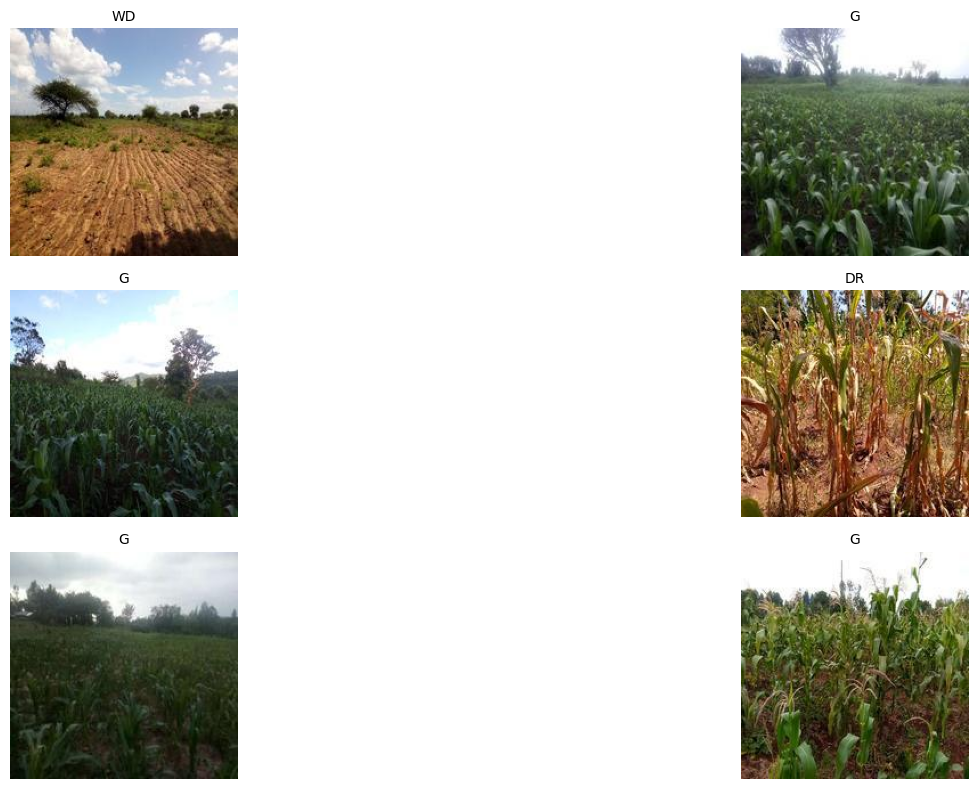

In [121]:
preview_images(0, n = 6)